In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA


In [ ]:
df = pd.read_csv("train.csv")
print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exercise 1: Data Scaling & Normalization

Age     177
Fare      0
dtype: int64


/tmp/ipython-input-351849719.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num["Age"].fillna(df_num["Age"].median(), inplace=True)
/tmp/ipython-input-351849719.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,Age,Fare,Age_Zscore,Fare_Zscore,Age_MinMax,Fare_MinMax
0,22.0,7.2500,-0.565736,-0.502445,0.271174,0.014151
1,38.0,71.2833,0.663861,0.786845,0.472229,0.139136
2,26.0,7.9250,-0.258337,-0.488854,0.321438,0.015469
3,35.0,53.1000,0.433312,0.420730,0.434531,0.103644
4,35.0,8.0500,0.433312,-0.486337,0.434531,0.015713


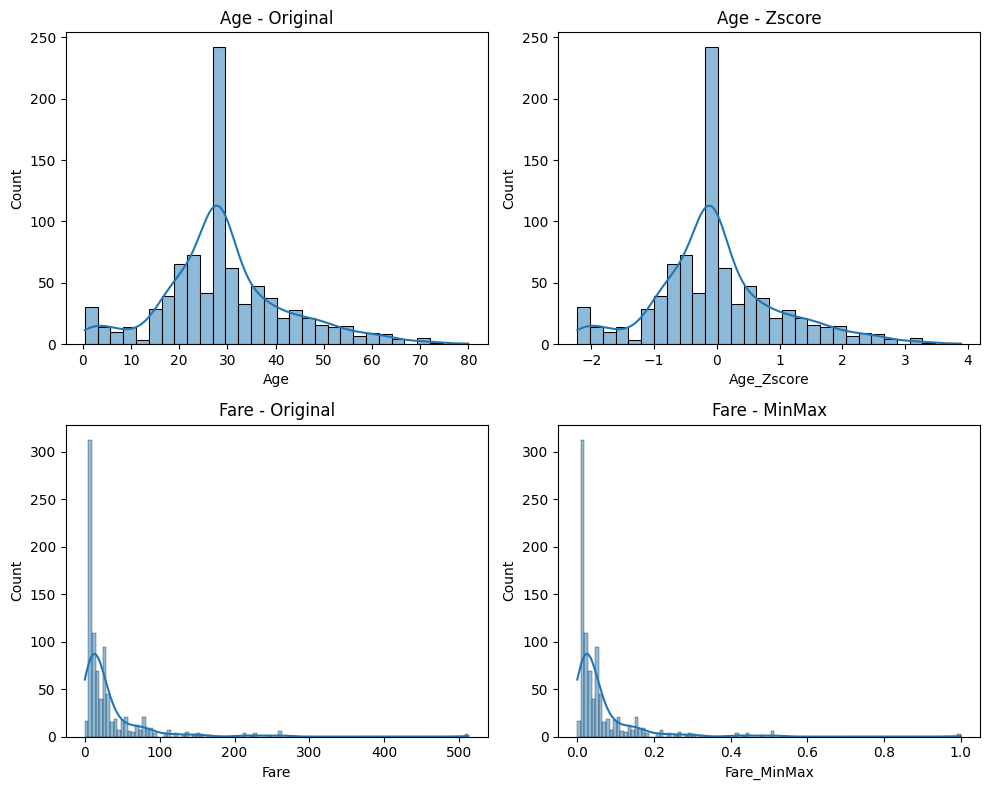

In [ ]:
# Select numerical columns
num_cols = ["Age", "Fare"]
df_num = df[num_cols].copy()

# Check missing
print(df_num.isna().sum())

# Fill missing values with median
df_num["Age"].fillna(df_num["Age"].median(), inplace=True)
df_num["Fare"].fillna(df_num["Fare"].median(), inplace=True)

# Standardization (Z-score)
scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(df_num), columns=[f"{c}_Zscore" for c in num_cols])

# Min-Max Normalization
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_num), columns=[f"{c}_MinMax" for c in num_cols])

# Merge to compare
df_scaled = pd.concat([df_num, df_std, df_minmax], axis=1)
display(df_scaled.head())

# Visualize before vs after
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.histplot(df_scaled["Age"], kde=True, ax=axes[0,0]); axes[0,0].set_title("Age - Original")
sns.histplot(df_scaled["Age_Zscore"], kde=True, ax=axes[0,1]); axes[0,1].set_title("Age - Zscore")
sns.histplot(df_scaled["Fare"], kde=True, ax=axes[1,0]); axes[1,0].set_title("Fare - Original")
sns.histplot(df_scaled["Fare_MinMax"], kde=True, ax=axes[1,1]); axes[1,1].set_title("Fare - MinMax")
plt.tight_layout()
plt.show()


## Exercise 2 — Creating Composite Features

         FamilySize  Survived
IsAlone                      
0          3.276836  0.505650
1          1.000000  0.303538


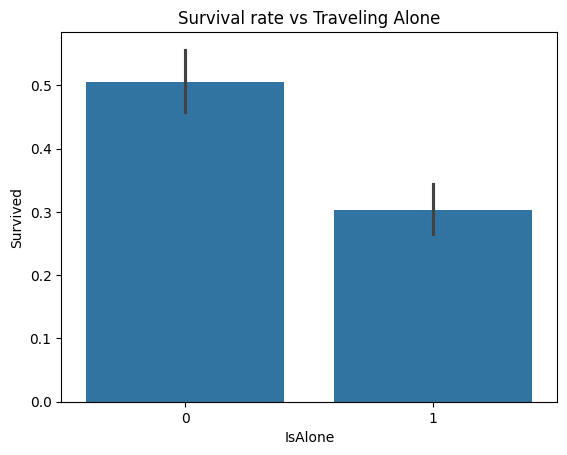

In [ ]:
# Creating FamilySize and IsAlone
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Checking relation with survival
print(df[["FamilySize", "IsAlone", "Survived"]].groupby(["IsAlone"]).mean())

# Visualizing
sns.barplot(x="IsAlone", y="Survived", data=df)
plt.title("Survival rate vs Traveling Alone")
plt.show()


## Exercise 3 — Normalization Comparison (Titanic)

/tmp/ipython-input-3525064698.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipython-input-3525064698.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

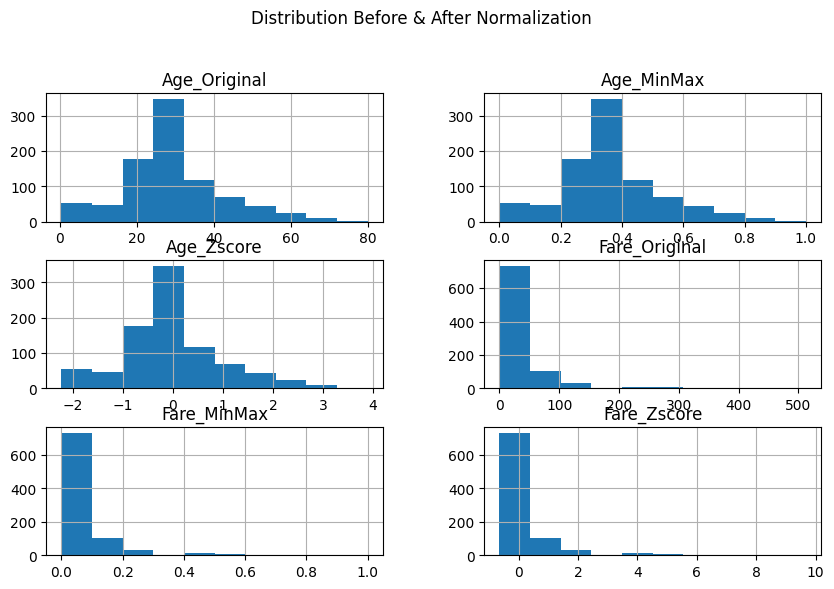

In [ ]:
# Reuse 'Age' and 'Fare'
data = df[["Age", "Fare"]].copy()
data["Age"].fillna(data["Age"].median(), inplace=True)
data["Fare"].fillna(data["Fare"].median(), inplace=True)

# Min-Max and Z-score
minmax = MinMaxScaler().fit_transform(data)
zscore = StandardScaler().fit_transform(data)

# Combine results
df_norm_compare = pd.DataFrame({
    "Age_Original": data["Age"],
    "Age_MinMax": minmax[:,0],
    "Age_Zscore": zscore[:,0],
    "Fare_Original": data["Fare"],
    "Fare_MinMax": minmax[:,1],
    "Fare_Zscore": zscore[:,1]
})

# Visualize
df_norm_compare.hist(figsize=(10,6))
plt.suptitle("Distribution Before & After Normalization", y=1.02)
plt.show()


## Exercise 4 — Data Reduction & Aggregation

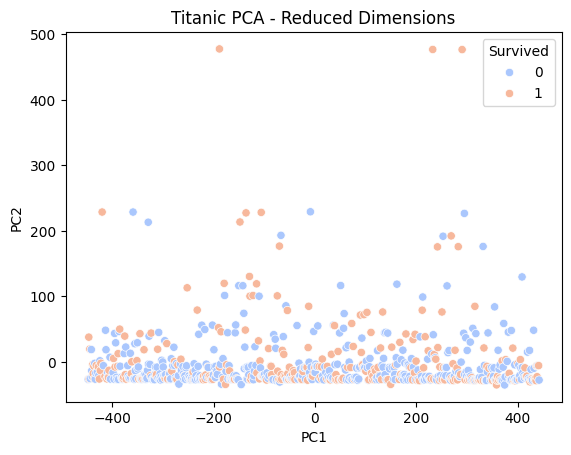

,Pclass,Fare,Age
0,1,84.154687,38.233441
1,2,20.662183,29.877630
2,3,13.675550,25.140620


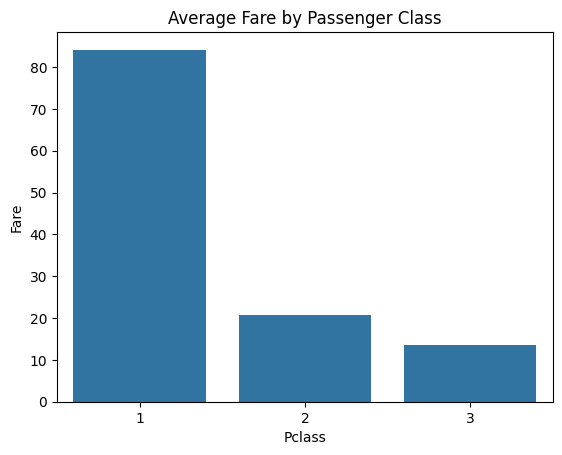

In [ ]:
# Select numeric features only
num_features = df.select_dtypes(include=[np.number]).dropna()

# PCA to reduce dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(num_features)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Survived'] = df['Survived']

# Visualize
sns.scatterplot(x="PC1", y="PC2", hue="Survived", data=pca_df, palette="coolwarm")
plt.title("Titanic PCA - Reduced Dimensions")
plt.show()

# Aggregation by 'Pclass'
agg_df = df.groupby("Pclass")[["Fare", "Age"]].mean().reset_index()
display(agg_df)

sns.barplot(x="Pclass", y="Fare", data=agg_df)
plt.title("Average Fare by Passenger Class")
plt.show()


## Exercise 5 : Normalizing E-Commerce Sales Data

In [ ]:
superstore = pd.read_csv("Superstore_Sales.csv", encoding='latin1')

superstore.head()

# Normalizing Sales and Profit
scaler = MinMaxScaler()
superstore[["Sales_normalized", "Profit_normalized"]] = scaler.fit_transform(superstore[["Sales", "Profit"]])

# Results
superstore[["Sales", "Sales_normalized", "Profit", "Profit_normalized"]].head()


,Sales,Sales_normalized,Profit,Profit_normalized
0,408.300,0.018016,106.140,0.447076
1,120.366,0.005297,36.036,0.442402
2,66.120,0.002901,29.640,0.441976
3,44.865,0.001962,-26.055,0.438263
4,113.670,0.005002,37.770,0.442518


## Exercise 6 — Aggregating Air Quality Data

In [ ]:
# Load Air Quality dataset
air = pd.read_csv("AirQualityIndia.csv")

# Convert Date to datetime
air["Date"] = pd.to_datetime(air["Date"], errors='coerce')

# Extract Month and Year
air["YearMonth"] = air["Date"].dt.to_period("M")

# Aggregate by Location and Month
air_monthly = air.groupby(["Location", "YearMonth"])[["PM2.5", "PM10", "NO2"]].mean().reset_index()

# Preview
air_monthly.head()

# Visualization
plt.figure(figsize=(10,5))
sns.lineplot(x="YearMonth", y="PM2.5", hue="Location", data=air_monthly)
plt.xticks(rotation=45)
plt.title("Monthly PM2.5 Trends by Location")
plt.show()
